# ============================================================
# Лабораторная работа №2. Ассоциативные правила
# Датасет: Groceries Market Basket
# Параметры: min_support = 0.03, min_confidence = 0.3
# ============================================================

Размер датасета: (9835, 32)
                 0                    1               2   \
0      citrus fruit  semi-finished bread       margarine   
1    tropical fruit               yogurt          coffee   
2        whole milk                  NaN             NaN   
3         pip fruit               yogurt   cream cheese    
4  other vegetables           whole milk  condensed milk   

                         3    4    5    6    7    8    9   ...   22   23   24  \
0               ready soups  NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN   
1                       NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN   
2                       NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN   
3              meat spreads  NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN   
4  long life bakery product  NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN   

    25   26   27   28   29   30   31  
0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
2  NaN 

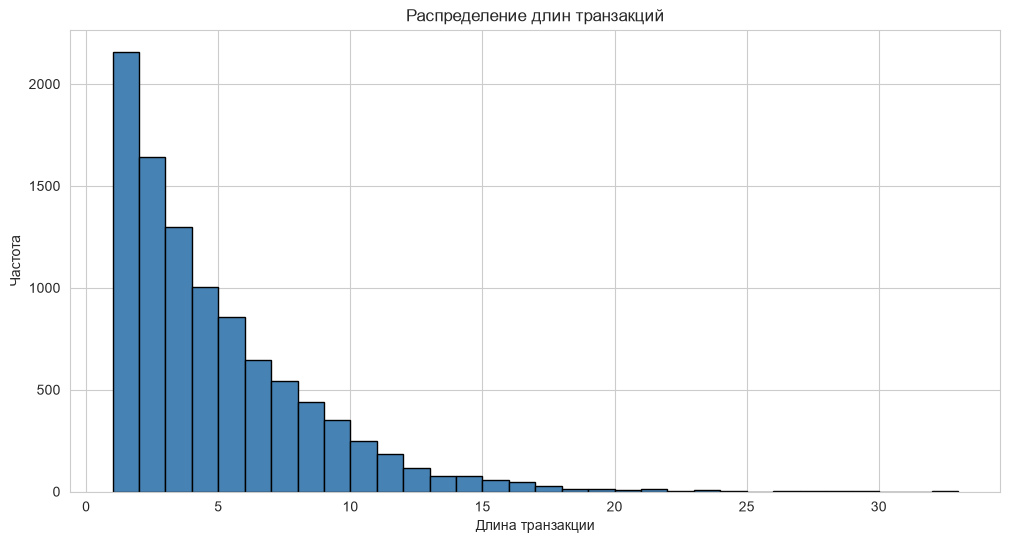

Статистики длин транзакций:
count    9835.000000
mean        4.409456
std         3.589385
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        32.000000
dtype: float64

Транзакций после очистки: 9835
Пример первой транзакции: ['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups'] ...
Уникальных товаров: 169


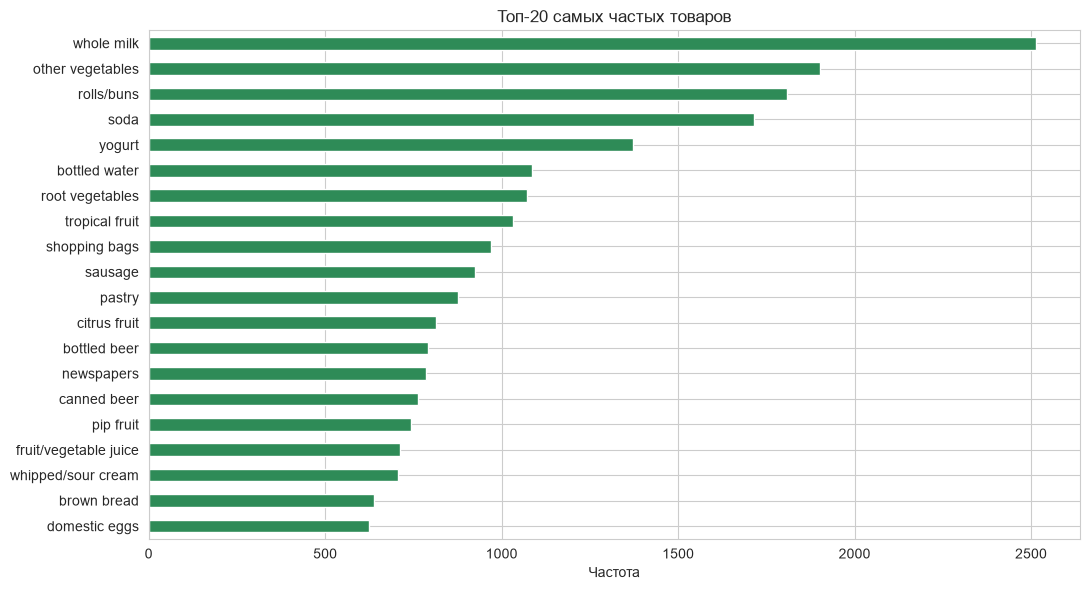


Размер бинарной матрицы: (9835, 169)
Плотность: 0.0261

Apriori: частых наборов = 63, правил = 14
Топ-10 правил по lift:
             antecedents         consequents   support  confidence      lift
2      (root vegetables)  (other vegetables)  0.047382    0.434701  2.246605
8              (sausage)        (rolls/buns)  0.030605    0.325758  1.771048
3       (tropical fruit)  (other vegetables)  0.035892    0.342054  1.767790
12  (whipped/sour cream)        (whole milk)  0.032232    0.449645  1.759754
10     (root vegetables)        (whole milk)  0.048907    0.448694  1.756031
5               (yogurt)  (other vegetables)  0.043416    0.311224  1.608457
11      (tropical fruit)        (whole milk)  0.042298    0.403101  1.577595
13              (yogurt)        (whole milk)  0.056024    0.401603  1.571735
7            (pip fruit)        (whole milk)  0.030097    0.397849  1.557043
4     (other vegetables)        (whole milk)  0.074835    0.386758  1.513634

FP-Growth: частых наборов = 63

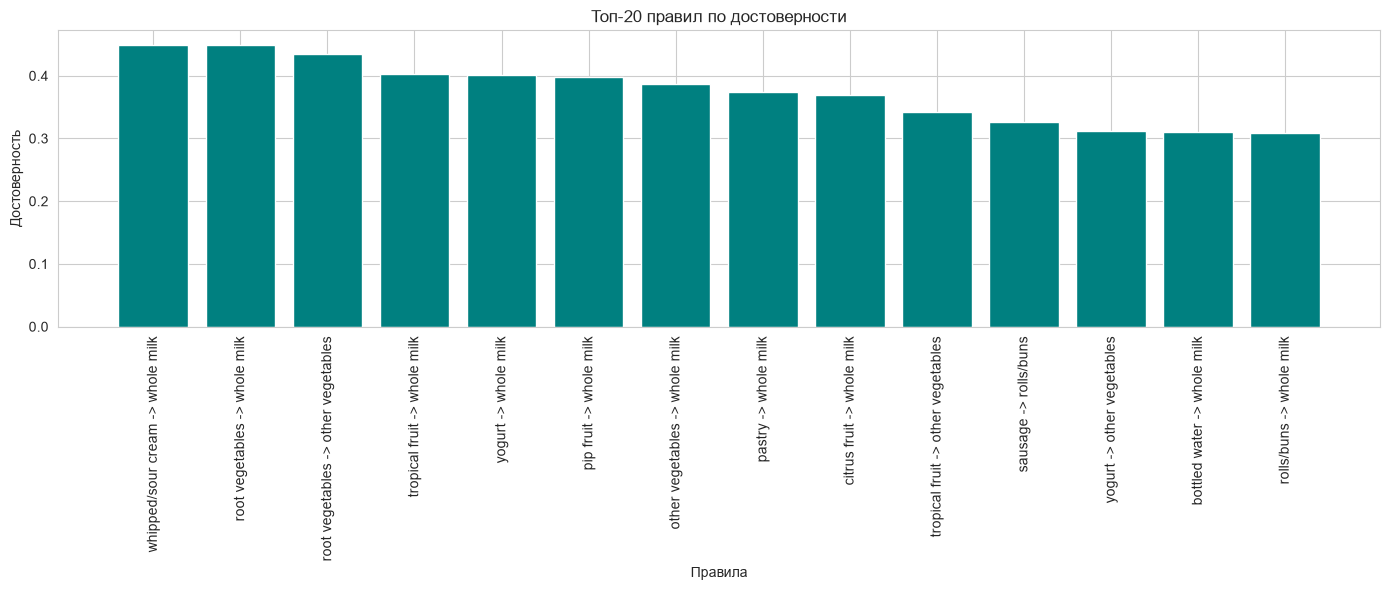

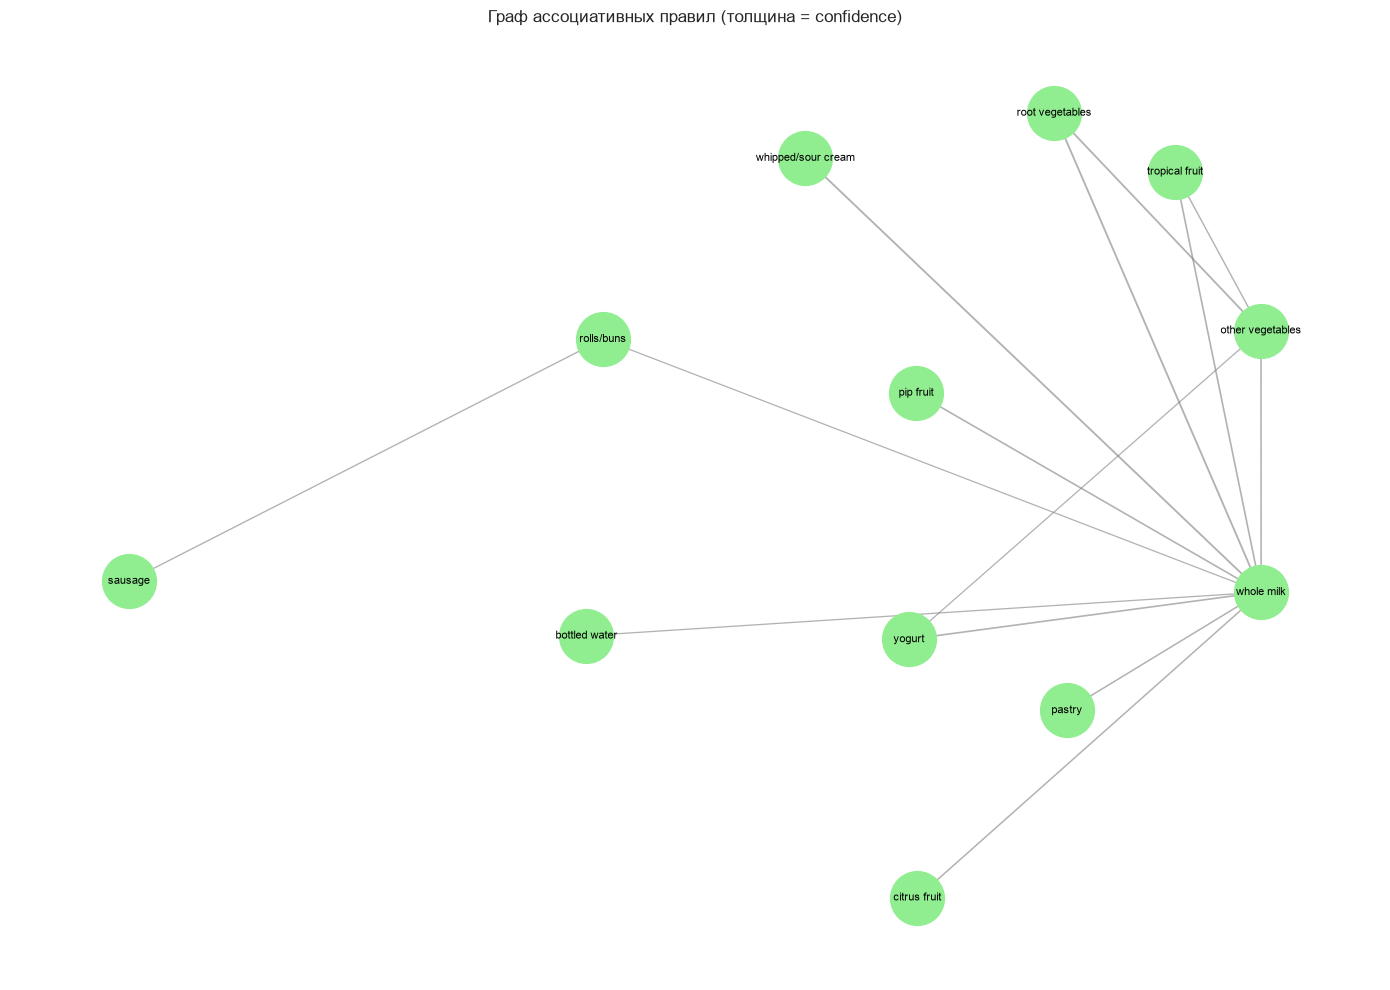

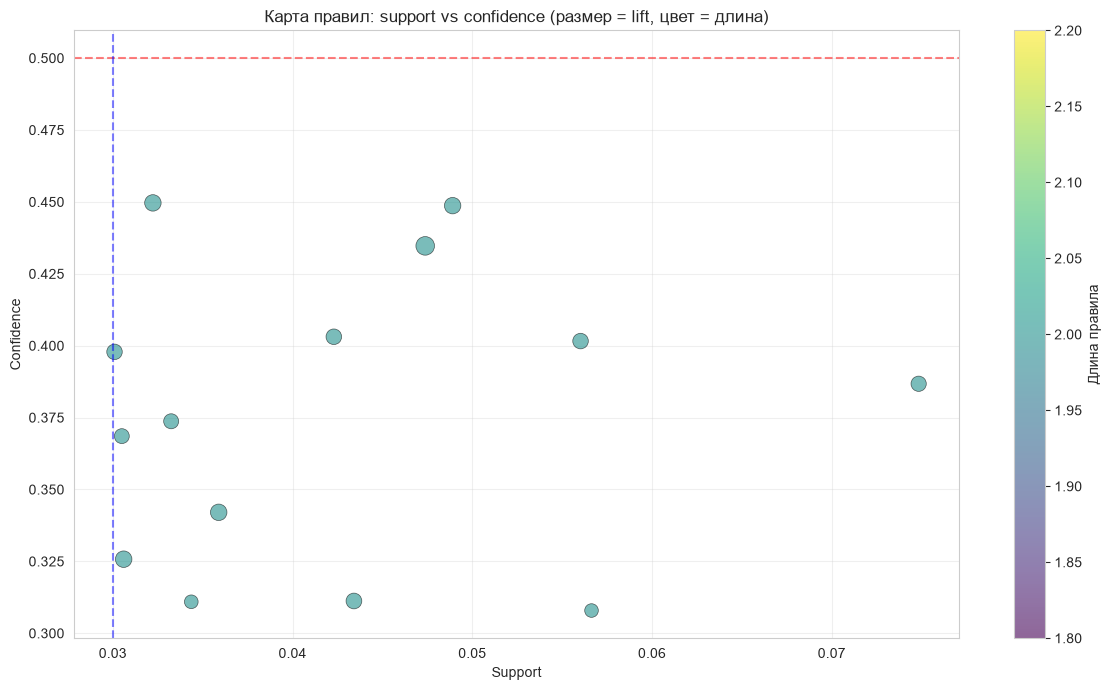


ВЫВОДЫ

1. Датасет: 9835 транзакций, 169 уникальных товаров.
2. При support=0.03, confidence=0.3:
   - Apriori  : 63 наборов, 14 правил.
   - FP-Growth: 63 наборов, 14 правил.
3. Полезных правил: 0. Тривиальных: 0.
4. Для бизнеса: правила с высоким lift → рекомендации для кросс-продаж.



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
RANDOM_STATE = 42

# ---- Загрузка данных ----
all_data = pd.read_csv('groceries.csv', header=None)
print("Размер датасета:", all_data.shape)
print(all_data.head())

# ---- Анализ длин транзакций ----
transaction_lengths = all_data.notnull().sum(axis=1)

plt.figure()
plt.hist(transaction_lengths, bins=range(1, max(transaction_lengths) + 2),
         color='steelblue', edgecolor='black')
plt.xlabel('Длина транзакции')
plt.ylabel('Частота')
plt.title('Распределение длин транзакций')
plt.show()

print("Статистики длин транзакций:")
print(transaction_lengths.describe())

# ---- Очистка данных ----
np_data = all_data.to_numpy()
np_data = [
    [elem for elem in row if isinstance(elem, str) and elem.strip() != '']
    for row in np_data
]
np_data = [row for row in np_data if len(row) > 0]

print("\nТранзакций после очистки:", len(np_data))
print("Пример первой транзакции:", np_data[0][:5], "...")

# ---- Уникальные товары ----
unique_items = set()
for row in np_data:
    for elem in row:
        unique_items.add(elem)

print("Уникальных товаров:", len(unique_items))

all_items_flat = [item for row in np_data for item in row]
item_counts = pd.Series(all_items_flat).value_counts()

plt.figure(figsize=(11, 6))
item_counts.head(20).plot(kind='barh', color='seagreen')
plt.gca().invert_yaxis()
plt.title('Топ-20 самых частых товаров')
plt.xlabel('Частота')
plt.tight_layout()
plt.show()

# ---- One-hot encoding ----
te = TransactionEncoder()
te_ary = te.fit(np_data).transform(np_data)
data = pd.DataFrame(te_ary, columns=te.columns_)

print("\nРазмер бинарной матрицы:", data.shape)
print("Плотность:", round(data.values.mean(), 4))

# ---- Apriori ----
MIN_SUPPORT = 0.03
MIN_CONFIDENCE = 0.3

freq_apriori = apriori(data, min_support=MIN_SUPPORT, use_colnames=True)
freq_apriori['length'] = freq_apriori['itemsets'].apply(len)

rules_apriori = association_rules(freq_apriori,
                                   metric='confidence',
                                   min_threshold=MIN_CONFIDENCE)
rules_apriori = rules_apriori.sort_values('lift', ascending=False)

print("\n" + "=" * 60)
print(f"Apriori: частых наборов = {len(freq_apriori)}, "
      f"правил = {len(rules_apriori)}")
print("Топ-10 правил по lift:")
print(rules_apriori[['antecedents', 'consequents',
                      'support', 'confidence', 'lift']].head(10))

# ---- FP-Growth ----
freq_fpg = fpgrowth(data, min_support=MIN_SUPPORT, use_colnames=True)
freq_fpg['length'] = freq_fpg['itemsets'].apply(len)

rules_fpg = association_rules(freq_fpg,
                               metric='confidence',
                               min_threshold=MIN_CONFIDENCE)

print("\n" + "=" * 60)
print(f"FP-Growth: частых наборов = {len(freq_fpg)}, "
      f"правил = {len(rules_fpg)}")
print("Сравнение Apriori vs FP-Growth:")
print(f"Apriori  : {len(freq_apriori)} наборов, {len(rules_apriori)} правил")
print(f"FP-Growth: {len(freq_fpg)} наборов, {len(rules_fpg)} правил")

# ---- Полезные и тривиальные правила ----
useful = rules_apriori[
    (rules_apriori['lift'] > 1.3) &
    (rules_apriori['confidence'] > 0.5)
].sort_values('lift', ascending=False)

trivial = rules_apriori[
    (rules_apriori['lift'] >= 0.95) &
    (rules_apriori['lift'] <= 1.05)
]

print(f"\nПолезных правил (lift>1.3, conf>0.5): {len(useful)}")
print(f"Тривиальных правил (lift≈1): {len(trivial)}")

# ---- Топ-20 правил по confidence ----
r_disp = rules_apriori.copy()
r_disp['antecedents'] = r_disp['antecedents'].apply(lambda x: ', '.join(list(x)))
r_disp['consequents'] = r_disp['consequents'].apply(lambda x: ', '.join(list(x)))
r_disp['label'] = r_disp['antecedents'] + ' -> ' + r_disp['consequents']

top_rules = r_disp.sort_values('confidence', ascending=False).head(20)

plt.figure(figsize=(14, 6))
plt.bar(top_rules['label'], top_rules['confidence'], color='teal')
plt.xlabel("Правила")
plt.ylabel("Достоверность")
plt.title("Топ-20 правил по достоверности")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# ---- Граф правил ----
G = nx.DiGraph()
for _, row in rules_apriori.head(40).iterrows():
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    G.add_edge(ant, con, weight=row['confidence'], lift=row['lift'])

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.8, seed=RANDOM_STATE)
weights = [G[u][v]['weight'] * 3 for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=1500, node_color='lightgreen')
nx.draw_networkx_edges(G, pos, width=weights, alpha=0.6,
                        edge_color='gray', arrows=True, arrowsize=15)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title('Граф ассоциативных правил (толщина = confidence)')
plt.axis('off')
plt.tight_layout()
plt.show()

# ---- Своя визуализация ----
rules_apriori['total_len'] = rules_apriori['antecedents'].apply(len) + \
                              rules_apriori['consequents'].apply(len)

plt.figure(figsize=(12, 7))
sc = plt.scatter(
    rules_apriori['support'],
    rules_apriori['confidence'],
    s=rules_apriori['lift'] * 80,
    c=rules_apriori['total_len'],
    cmap='viridis', alpha=0.6,
    edgecolors='black', linewidths=0.5
)
plt.colorbar(sc, label='Длина правила')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Карта правил: support vs confidence (размер = lift, цвет = длина)')
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5)
plt.axvline(0.03, color='blue', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---- Выводы ----
print("\n" + "=" * 60)
print("ВЫВОДЫ")
print("=" * 60)
print(f"""
1. Датасет: {len(np_data)} транзакций, {len(unique_items)} уникальных товаров.
2. При support={MIN_SUPPORT}, confidence={MIN_CONFIDENCE}:
   - Apriori  : {len(freq_apriori)} наборов, {len(rules_apriori)} правил.
   - FP-Growth: {len(freq_fpg)} наборов, {len(rules_fpg)} правил.
3. Полезных правил: {len(useful)}. Тривиальных: {len(trivial)}.
4. Для бизнеса: правила с высоким lift → рекомендации для кросс-продаж.
""")